<a href="https://colab.research.google.com/github/mrabdullah99/maize-nutrient-deficiency-detection/blob/main/maize_deficiency_efficientnet_b2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.cm as cm
import cv2

from google.colab import drive
import json
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("Keras Version", keras.__version__)


TensorFlow Version: 2.20.0
Keras Version 3.13.2


In [4]:
!python --version

Python 3.12.13


In [5]:
gpu_devices = tf.config.list_physical_devices('GPU')
print(gpu_devices)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!rm -rf /content/maize_dataset
!rm -f /content/maize_dataset.zip

In [8]:
# Now copy + unzip locally, no conflicts
!cp /content/drive/MyDrive/maize_dataset.zip /content/maize_dataset.zip
!unzip -q /content/maize_dataset.zip -d /content/maize_dataset
!rm /content/maize_dataset.zip

In [9]:
import os
root = '/content/maize_dataset/maize_dataset'
for split in os.listdir(root):
    split_path = os.path.join(root, split)
    if os.path.isdir(split_path):
        print(f"\n{split}/")
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                n = len(os.listdir(cls_path))
                print(f"  {cls}: {n} files")


train/
  ALL Present: 1176 files
  ALLAB: 1944 files
  KAB: 3441 files
  NAB: 1228 files
  PAB: 2970 files
  ZNAB: 2036 files

test/
  ALL Present: 294 files
  ALLAB: 486 files
  KAB: 860 files
  NAB: 307 files
  PAB: 2376 files
  ZNAB: 509 files


In [10]:
DATASET_PATH = "/content/maize_dataset/maize_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12795 files belonging to 6 classes.
Using 10236 files for training.
Found 12795 files belonging to 6 classes.
Using 2559 files for validation.


In [12]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 4832 files belonging to 6 classes.


In [13]:
class_names = train_ds.class_names
print(class_names)
NUM_CLASSES = len(class_names)

['ALL Present', 'ALLAB', 'KAB', 'NAB', 'PAB', 'ZNAB']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_ds.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Convert image tensor to an integer numpy array for rendering
        plt.imshow(images[i].numpy().astype("uint8"))

        # Find the index of the correct folder label (argmax reverses categorical one-hot encoding)
        label_idx = np.argmax(labels[i])

        plt.title(class_names[label_idx], fontsize=10)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.10),
])

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.7591 - loss: 0.7613 - val_accuracy: 0.8538 - val_loss: 0.4898 - learning_rate: 0.0010
Epoch 2/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 38s 99ms/step - accuracy: 0.8640 - loss: 0.4479 - val_accuracy: 0.8808 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 3/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.8815 - loss: 0.3840 - val_accuracy: 0.8964 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 4/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8901 - loss: 0.3473 - val_accuracy: 0.9058 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 5/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.8962 - loss: 0.3165 - val_accuracy: 0.9101 - val_loss: 0.2745 - learning_rate: 0.0010
Epoch 6/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - accuracy: 0.9008 - loss: 0.2978 - val_accuracy: 0.9156 - val_loss: 0.2638 - learning_rate: 0.0010
Epoch 7/15
320/320 ━━━━━━━━━━━━━━━━━━━━ 32s 99ms/step - accuracy: 0.9039 -

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop_fine = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr_fine = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_fine, reduce_lr_fine]
)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - accuracy: 0.7761 - loss: 0.6274 - val_accuracy: 0.8957 - val_loss: 0.3033 - learning_rate: 1.0000e-05
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8493 - loss: 0.4470 - val_accuracy: 0.9058 - val_loss: 0.2668 - learning_rate: 1.0000e-05
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.8750 - loss: 0.3641 - val_accuracy: 0.9172 - val_loss: 0.2319 - learning_rate: 1.0000e-05
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8872 - loss: 0.3318 - val_accuracy: 0.9234 - val_loss: 0.2083 - learning_rate: 1.0000e-05
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 46s 129ms/step - accuracy: 0.8991 - loss: 0.2995 - val_accuracy: 0.9301 - val_loss: 0.1901 - learning_rate: 1.0000e-05
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.9020 - loss: 0.2858 - val_accuracy: 0.9375 - val_loss: 0.1708 - learning_rate: 1.0000e-05
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 37s 11

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9630 - loss: 0.1124
Test Accuracy: 0.9629552960395813


In [ ]:
y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)
y_pred = np.argmax(
    model.predict(test_ds),
    axis=1
)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

151/151 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step
              precision    recall  f1-score   support

 ALL Present       0.94      0.89      0.91       294
       ALLAB       0.98      0.99      0.99       486
         KAB       0.93      0.98      0.96       860
         NAB       1.00      0.99      1.00       307
         PAB       0.98      0.97      0.98      2376
        ZNAB       0.89      0.91      0.90       509

    accuracy                           0.96      4832
   macro avg       0.95      0.96      0.95      4832
weighted avg       0.96      0.96      0.96      4832



In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

In [ ]:
# !mkdir -p "/content/drive/MyDrive/ML_Models"

In [ ]:
model.save("/content/drive/MyDrive/ML_Models/maize_nutrient_model_v3.keras")

In [14]:
with open("/content/drive/MyDrive/ML_Models/maize_nutrient_class_names_v3.json", "w") as f:
    json.dump(class_names, f)

In [15]:
model_path = "/content/drive/MyDrive/ML_Models/maize_nutrient_model_v3.keras"
json_path = "/content/drive/MyDrive/ML_Models/maize_nutrient_class_names_v3.json"

deployed_model = tf.keras.models.load_model(model_path)

# 2. Load the class names mapping
with open(json_path, "r") as f:
    class_names = json.load(f)

print("Model and Class Names loaded successfully!")
print("Your categories are:", class_names)

Model and Class Names loaded successfully!
Your categories are: ['ALL Present', 'ALLAB', 'KAB', 'NAB', 'PAB', 'ZNAB']


In [ ]:
import random

for images, labels in test_ds.take(15):
    idx = random.randint(0, len(images)-1)

    img = images[idx].numpy().astype("uint8")
    true_label = class_names[labels[idx]]

    pred = deployed_model.predict(tf.expand_dims(images[idx], 0))
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100
    color = "green" if true_label == pred_label else "red"

    plt.imshow(img)
    plt.title(f"True: {true_label} | Pred: {pred_label} | Conf: {confidence:.2f}%",
    color=color)
    plt.axis("off")
    plt.show()

In [20]:
label_map = {
    "ALL Present": "Multiple Nutrient Deficiencies",
    "ALLAB": "Healthy Leaf",
    "NAB": "Nitrogen Deficiency",
    "PAB": "Phosphorus Deficiency",
    "KAB": "Potassium Deficiency",
    "ZNAB": "Zinc Deficiency"
}
# Fertilizer Recommendations
recommendations = {
    "Healthy Leaf":
        "No nutrient deficiency detected.",
    "Nitrogen Deficiency":
        "Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural practices.",
    "Phosphorus Deficiency":
        "Apply phosphorus fertilizer such as DAP based on soil recommendations.",
    "Potassium Deficiency":
        "Apply potassium fertilizer such as Muriate of Potash (MOP).",
    "Zinc Deficiency":
        "Apply Zinc Sulfate after confirming deficiency with local recommendations.",
    "Multiple Nutrient Deficiencies":
        "Multiple nutrient deficiencies detected. A soil test is recommended before applying fertilizers."
}


In [39]:
def test_from_class(folder_name, num_images=4):

    path = f"/content/maize_dataset/maize_dataset/test/{folder_name}"
    # Read only image files
    files = [
        f for f in os.listdir(path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    # Prevent requesting more images than available
    num_images = min(num_images, len(files))

    # Choose different random images
    selected_files = random.sample(files, num_images)

    plt.figure(figsize=(4 * num_images, 5))

    for i, file in enumerate(selected_files):

        img_path = os.path.join(path, file)
        # Load image
        img = tf.keras.utils.load_img(
            img_path,
            target_size=(224, 224)
        )

        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        # Predict
        pred = deployed_model.predict(img_array, verbose=0)

        pred_index = np.argmax(pred)
        pred_class = class_names[pred_index]
        confidence = np.max(pred) * 100

        # Convert to readable names
        actual_name = label_map[folder_name]
        predicted_name = label_map[pred_class]

        recommendation = recommendations[predicted_name]

        # Green if correct, Red if incorrect
        title_color = "green" if pred_class == folder_name else "red"

        # Display image
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(
            f"Actual:\n{actual_name}\n\n"
            f"Predicted:\n{predicted_name}\n\n"
            f"Confidence:\n{confidence:.2f}%",
            color=title_color,
            fontsize=10
        )
        plt.axis("off")

        # Print details
        print("=" * 70)
        print(f"Image            : {file}")
        print(f"Actual Class     : {actual_name}")
        print(f"Predicted Class  : {predicted_name}")
        print(f"Confidence       : {confidence:.2f}%")
        print(f"Recommendation   : {recommendation}")

    plt.tight_layout()
    plt.show()

Image            : 0931_0.jpg
Actual Class     : Healthy Leaf
Predicted Class  : Healthy Leaf
Confidence       : 100.00%
Recommendation   : No nutrient deficiency detected.
Image            : 1106_1.jpg
Actual Class     : Healthy Leaf
Predicted Class  : Healthy Leaf
Confidence       : 97.24%
Recommendation   : No nutrient deficiency detected.
Image            : 0797_2.jpg
Actual Class     : Healthy Leaf
Predicted Class  : Healthy Leaf
Confidence       : 99.93%
Recommendation   : No nutrient deficiency detected.
Image            : 0774_3.jpg
Actual Class     : Healthy Leaf
Predicted Class  : Healthy Leaf
Confidence       : 100.00%
Recommendation   : No nutrient deficiency detected.


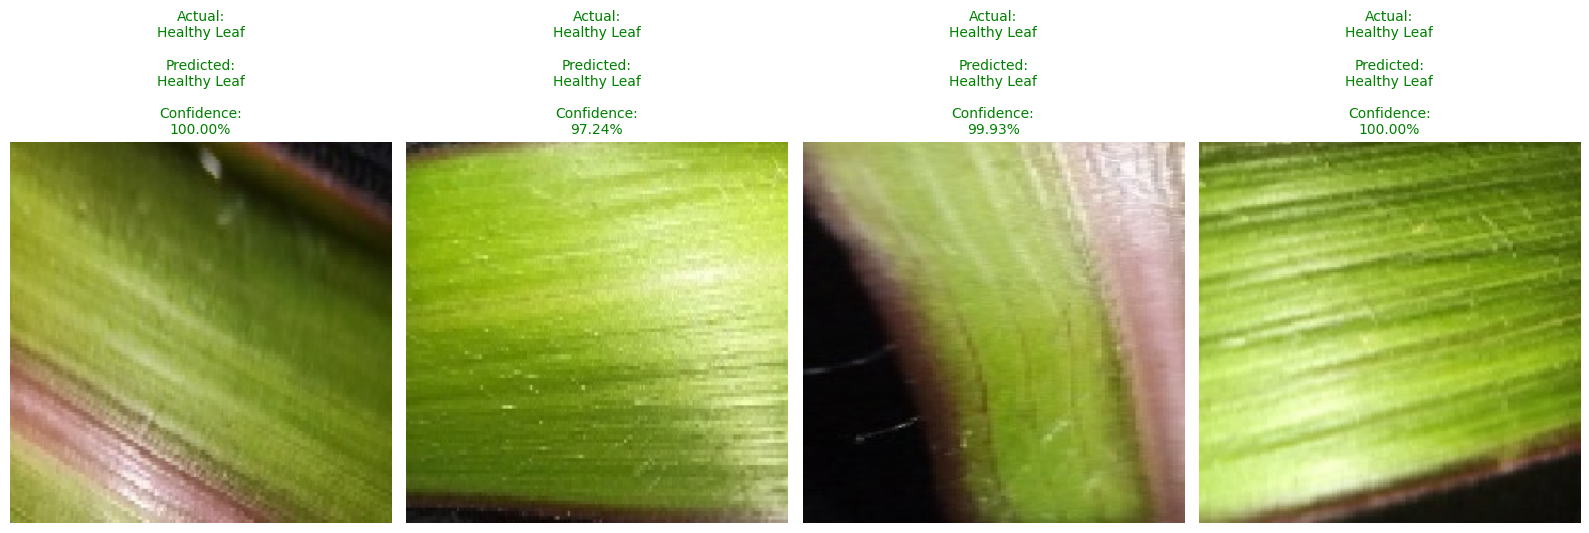

Image            : IMG20230330174348.jpg
Actual Class     : Nitrogen Deficiency
Predicted Class  : Nitrogen Deficiency
Confidence       : 100.00%
Recommendation   : Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural practices.
Image            : IMG20230330174734.jpg
Actual Class     : Nitrogen Deficiency
Predicted Class  : Nitrogen Deficiency
Confidence       : 99.99%
Recommendation   : Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural practices.
Image            : IMG20230319161636.jpg
Actual Class     : Nitrogen Deficiency
Predicted Class  : Nitrogen Deficiency
Confidence       : 95.09%
Recommendation   : Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural practices.
Image            : IMG20230330174847_01.jpg
Actual Class     : Nitrogen Deficiency
Predicted Class  : Nitrogen Deficiency
Confidence       : 99.99%
Recommendation   : Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural

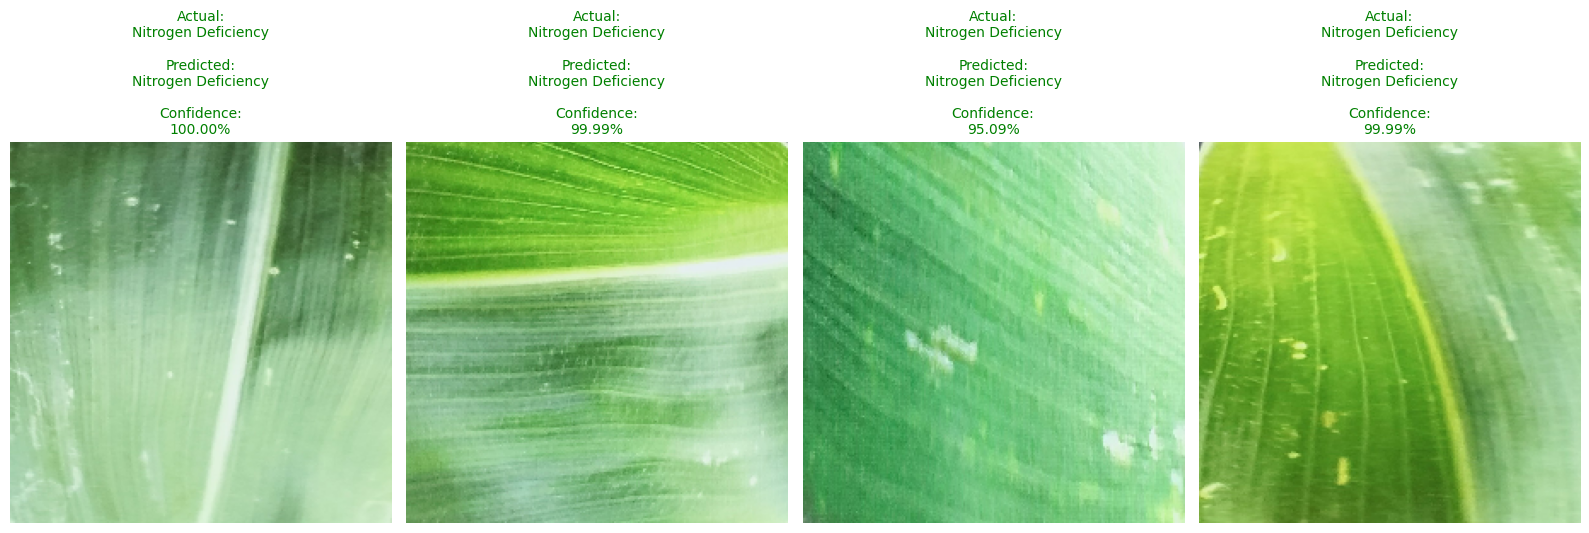

Image            : 1427_2.jpg
Actual Class     : Phosphorus Deficiency
Predicted Class  : Phosphorus Deficiency
Confidence       : 99.94%
Recommendation   : Apply phosphorus fertilizer such as DAP based on soil recommendations.
Image            : 1671_3.jpg
Actual Class     : Phosphorus Deficiency
Predicted Class  : Phosphorus Deficiency
Confidence       : 99.69%
Recommendation   : Apply phosphorus fertilizer such as DAP based on soil recommendations.
Image            : 1689_2.jpg
Actual Class     : Phosphorus Deficiency
Predicted Class  : Phosphorus Deficiency
Confidence       : 91.24%
Recommendation   : Apply phosphorus fertilizer such as DAP based on soil recommendations.
Image            : 1426_1.jpg
Actual Class     : Phosphorus Deficiency
Predicted Class  : Phosphorus Deficiency
Confidence       : 99.97%
Recommendation   : Apply phosphorus fertilizer such as DAP based on soil recommendations.


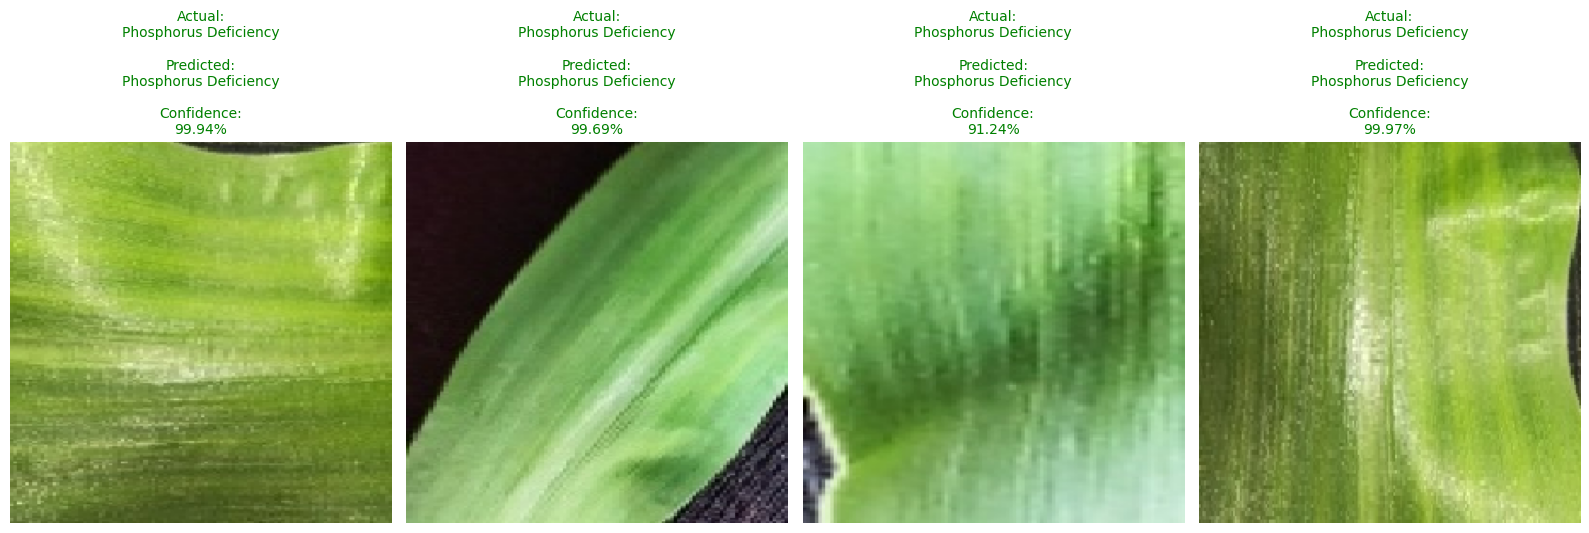

Image            : 0365_1_2.jpg
Actual Class     : Potassium Deficiency
Predicted Class  : Potassium Deficiency
Confidence       : 96.83%
Recommendation   : Apply potassium fertilizer such as Muriate of Potash (MOP).
Image            : 0652_1_0.jpg
Actual Class     : Potassium Deficiency
Predicted Class  : Potassium Deficiency
Confidence       : 99.93%
Recommendation   : Apply potassium fertilizer such as Muriate of Potash (MOP).
Image            : 0563_0_4.jpg
Actual Class     : Potassium Deficiency
Predicted Class  : Potassium Deficiency
Confidence       : 94.78%
Recommendation   : Apply potassium fertilizer such as Muriate of Potash (MOP).
Image            : 0488_2_1.jpg
Actual Class     : Potassium Deficiency
Predicted Class  : Zinc Deficiency
Confidence       : 68.32%
Recommendation   : Apply Zinc Sulfate after confirming deficiency with local recommendations.


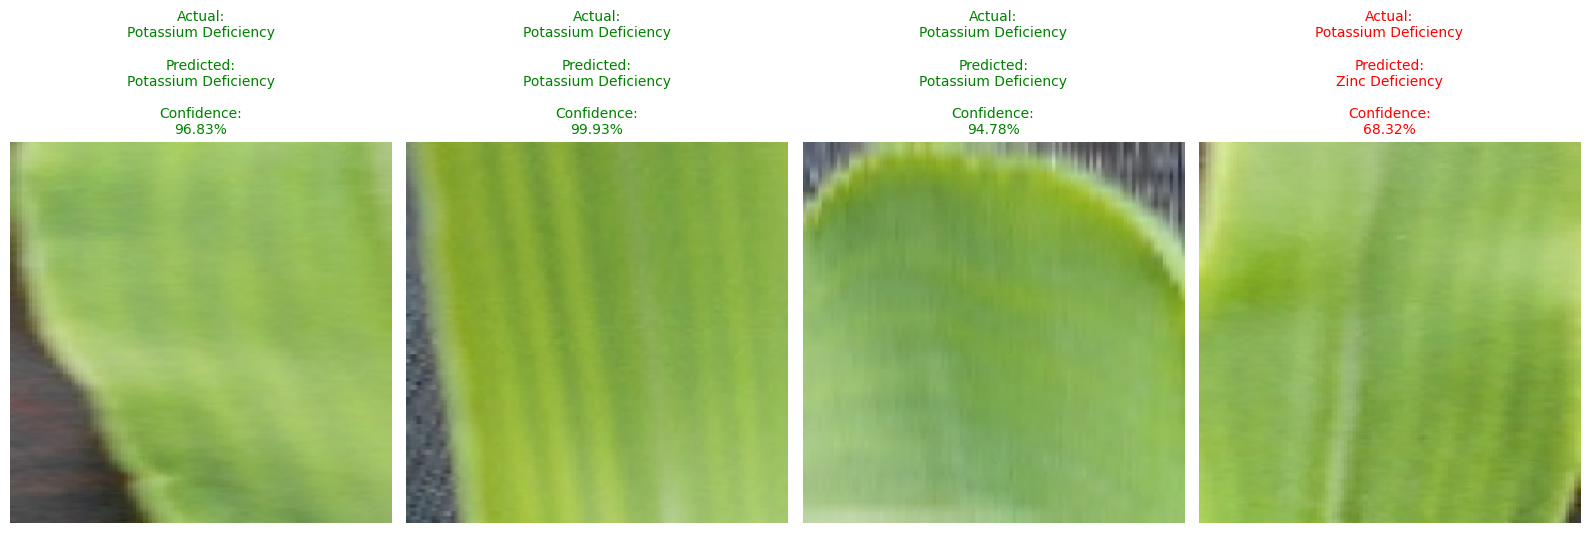

Image            : 1973_2.jpg
Actual Class     : Zinc Deficiency
Predicted Class  : Zinc Deficiency
Confidence       : 99.97%
Recommendation   : Apply Zinc Sulfate after confirming deficiency with local recommendations.
Image            : 1871_3.jpg
Actual Class     : Zinc Deficiency
Predicted Class  : Zinc Deficiency
Confidence       : 99.94%
Recommendation   : Apply Zinc Sulfate after confirming deficiency with local recommendations.
Image            : 1457_2.jpg
Actual Class     : Zinc Deficiency
Predicted Class  : Zinc Deficiency
Confidence       : 79.42%
Recommendation   : Apply Zinc Sulfate after confirming deficiency with local recommendations.
Image            : 2044_4.jpg
Actual Class     : Zinc Deficiency
Predicted Class  : Phosphorus Deficiency
Confidence       : 53.80%
Recommendation   : Apply phosphorus fertilizer such as DAP based on soil recommendations.


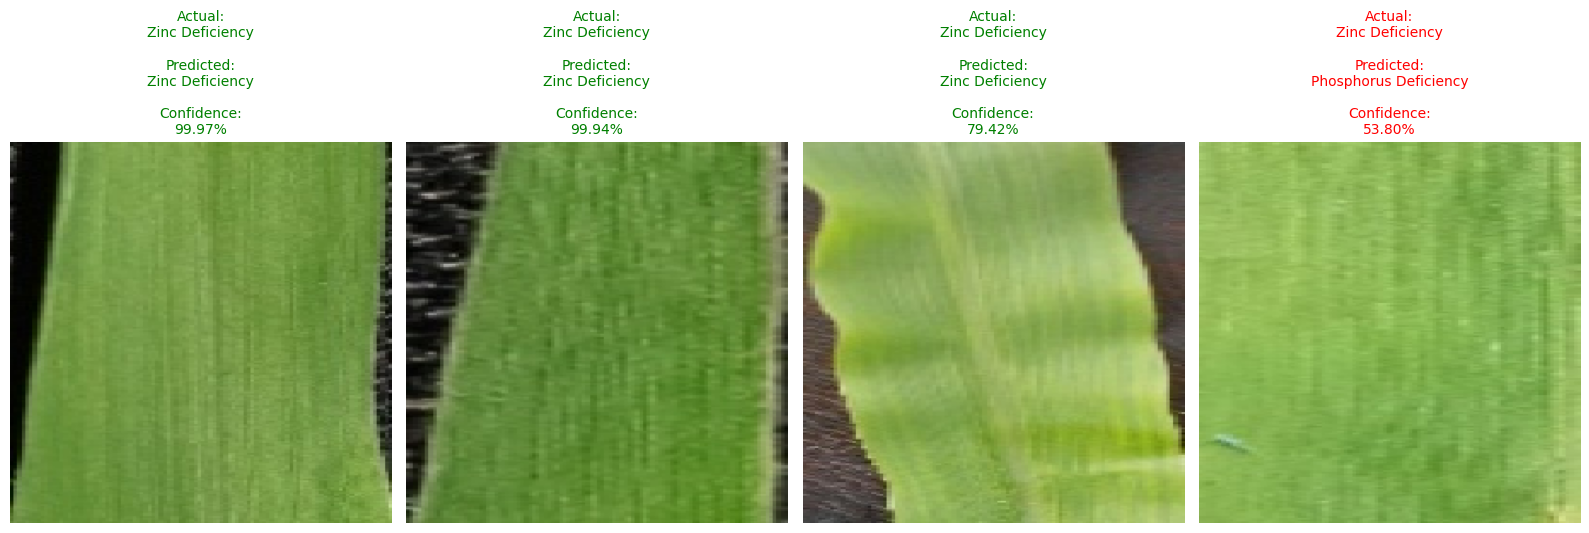

In [40]:
# test_from_class("ALL Present")
test_from_class("ALLAB")
test_from_class("NAB")
test_from_class("PAB")
test_from_class("KAB")
test_from_class("ZNAB")

In [26]:
def predict_leaf(image_path):
    # Load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224,224)
    )
    # Convert image to array
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    # Predict
    pred = deployed_model.predict(img_array, verbose=0)
    probabilities = pred[0]
    top3 = np.argsort(probabilities)[::-1][:3]
    pred_index = top3[0]
    pred_class = class_names[pred_index]
    confidence = probabilities[pred_index] * 100
    deficiency = label_map[pred_class]
    recommendation = recommendations[deficiency]
    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{deficiency}\nConfidence: {confidence:.2f}%"
    )
    plt.show()
    # Print results
    print("="*60)
    print(f"Prediction      : {deficiency}")
    print(f"Confidence      : {confidence:.2f}%")
    print("\nTop 3 Predictions")
    print("-" * 40)
    for i in top3:
      print(f"{label_map[class_names[i]]}: {probabilities[i] * 100:.2f}%")
    print(f"Recommendation  : {recommendation}")
    return deficiency, confidence

In [ ]:
predict_leaf("/content/maize_dataset/maize_dataset/test/PAB/0982_1.jpg")

In [29]:
!pip install opencv-python

In [30]:
for layer in deployed_model.layers:
    print(layer.name)

input_layer_7
sequential_2
efficientnetb0
global_average_pooling2d_2
dropout_2
dense_2


In [31]:
efficientnet = deployed_model.get_layer("efficientnetb0")

for layer in reversed(efficientnet.layers):
    if len(layer.output.shape) == 4:
        print(layer.name)
        break

top_activation


In [32]:
# Grad-CAM — Keras 3 compatible (TF 2.20+)
# Uses manual forward pass instead of building a new Model
# Works with nested submodels (EfficientNetB0 inside deployed_model)

# Get references to model parts we need
from keras.layers import GlobalAveragePooling2D, Dropout, Dense

augmentation_layer = deployed_model.layers[1]
efficientnet_layer = deployed_model.get_layer("efficientnetb0")

gap_layer = next(
    layer for layer in deployed_model.layers
    if isinstance(layer, GlobalAveragePooling2D)
)
dropout_layer = next(
    layer for layer in deployed_model.layers
    if isinstance(layer, Dropout)
)
dense_layer = next(
    layer for layer in deployed_model.layers
    if isinstance(layer, Dense)
)


def compute_gradcam(img_batch, class_index=None):
    """
    Manual forward pass through each layer so GradientTape
    can watch the conv output across the submodel boundary.

    img_batch: (1, 224, 224, 3) float32, raw pixels 0-255
    """
    img_tensor = tf.cast(img_batch, tf.float32)

    with tf.GradientTape() as tape:
        # Step through each part of the model manually
        x = augmentation_layer(img_tensor, training=False)
        x = tf.keras.applications.efficientnet.preprocess_input(x)

        # Run EfficientNet and capture the last conv output
        conv_output = efficientnet_layer(x, training=False)
        tape.watch(conv_output)

        # Rest of the head
        x = gap_layer(conv_output)
        x = dropout_layer(x, training=False)
        predictions = dense_layer(x)

        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_output)

    # Pool gradients spatially → one weight per filter
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted combination of feature maps
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap).numpy()

    # ReLU + normalize to [0, 1]
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    confidence = float(predictions[0][class_index]) * 100

    return heatmap, class_index, confidence


def overlay_gradcam(img_uint8, heatmap, alpha=0.4):
    h, w = img_uint8.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    colormap = plt.colormaps['jet']
    heatmap_colored = (colormap(heatmap_resized)[:, :, :3] * 255).astype(np.uint8)
    return cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)


def predict_with_gradcam(image_path, class_index=None, alpha=0.4):
    img       = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype(np.float32)
    img_uint8 = img_array.astype(np.uint8)
    img_batch = np.expand_dims(img_array, axis=0)

    heatmap, pred_index, confidence = compute_gradcam(img_batch, class_index)
    overlay = overlay_gradcam(img_uint8, heatmap, alpha)

    pred_class_raw = class_names[pred_index]
    pred_deficiency = label_map[pred_class_raw]
    recommendation  = recommendations[pred_deficiency]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_uint8);  axes[0].set_title("Original Image");             axes[0].axis("off")
    axes[1].imshow(heatmap, cmap="jet"); axes[1].set_title("Grad-CAM Heatmap\n(red = most influential)"); axes[1].axis("off")
    axes[2].imshow(overlay);   axes[2].set_title(f"Prediction: {pred_deficiency}\nConfidence: {confidence:.2f}%", color="green"); axes[2].axis("off")

    plt.suptitle(f"Grad-CAM — {pred_deficiency}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("/content/gradcam_result.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("=" * 60)
    print(f"Prediction      : {pred_deficiency}")
    print(f"Confidence      : {confidence:.2f}%")
    print(f"Recommendation  : {recommendation}")
    print("=" * 60)

    return pred_deficiency, confidence, heatmap


def gradcam_all_classes(image_path, alpha=0.35):
    img       = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype(np.float32)
    img_uint8 = img_array.astype(np.uint8)
    img_batch = np.expand_dims(img_array, axis=0)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, cls in enumerate(class_names):
        heatmap, _, confidence = compute_gradcam(img_batch, class_index=i)
        overlay = overlay_gradcam(img_uint8, heatmap, alpha)
        axes[i].imshow(overlay)
        axes[i].set_title(f"{label_map[cls]}\n({confidence:.1f}%)", fontsize=10)
        axes[i].axis("off")

    plt.suptitle("Grad-CAM — All 6 Classes", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/gradcam_all_classes.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Grad-CAM functions ready. Run: predict_with_gradcam('path/to/image.jpg')")

Grad-CAM functions ready. Run: predict_with_gradcam('path/to/image.jpg')


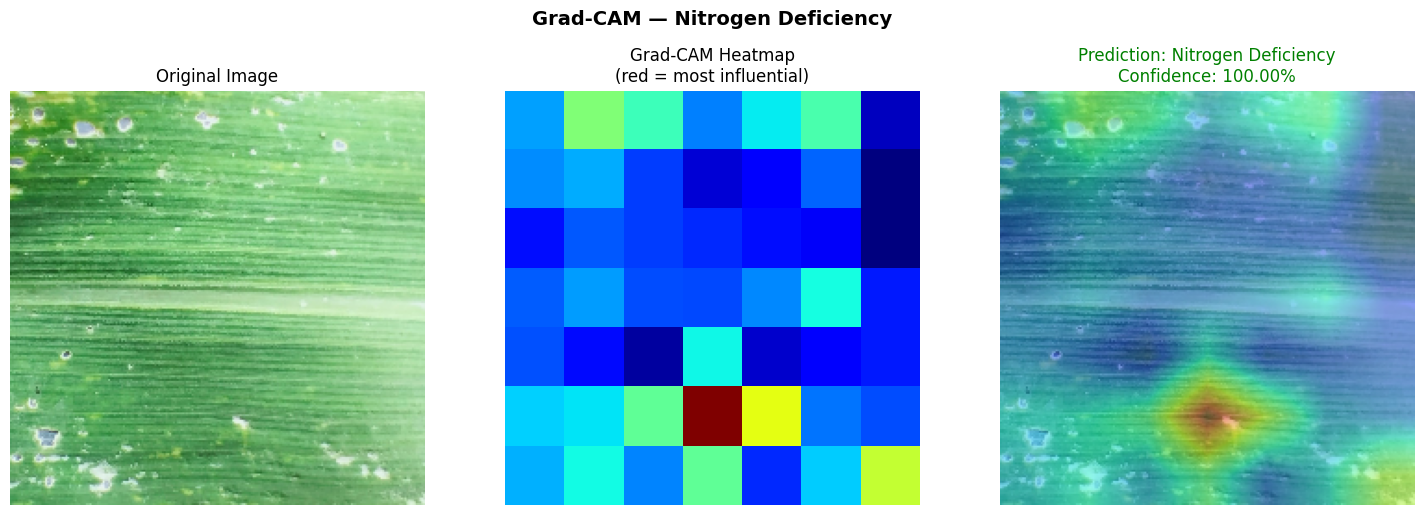

Prediction      : Nitrogen Deficiency
Confidence      : 100.00%
Recommendation  : Apply nitrogen fertilizer (e.g., Urea) according to recommended agricultural practices.


('Nitrogen Deficiency',
 99.99722242355347,
 array([[0.28209853, 0.50770456, 0.4238975 , 0.25253367, 0.35623473,
         0.43891546, 0.05640896],
        [0.26397777, 0.2967372 , 0.18635972, 0.07595304, 0.12808932,
         0.22552425, 0.        ],
        [0.13699807, 0.21197304, 0.18733558, 0.16686945, 0.13739707,
         0.10830332, 0.        ],
        [0.21527813, 0.28089687, 0.20096102, 0.19551829, 0.2603589 ,
         0.37508103, 0.14918864],
        [0.20320323, 0.13432872, 0.02942109, 0.36930248, 0.06833952,
         0.11466701, 0.1516946 ],
        [0.33119676, 0.34852773, 0.46697706, 1.        , 0.6260532 ,
         0.24062501, 0.20312151],
        [0.29805633, 0.37479052, 0.25761688, 0.46522963, 0.16661823,
         0.32725853, 0.5881448 ]], dtype=float32))

In [35]:
predict_with_gradcam("/content/maize_dataset/maize_dataset/test/NAB/IMG20230319153645.jpg")